In [25]:
import pandas as pd
import numpy as np

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
sns.set_style("whitegrid")

# Feature Engineering

In [28]:
import pandas as pd
import numpy as np

In [29]:
df_line_items = pd.read_csv("data/sales_line_items.csv")
df_events = pd.read_csv("data/events.csv")
df_catalogue = pd.read_csv("data/catalogue.csv")

In [30]:
df_line_items['date'] = pd.to_datetime(df_line_items['date'])
df_events['date'] = pd.to_datetime(df_events['date'])


In [31]:
daily_sku = df_line_items.groupby(['date', 'sku']).agg(
    total_units=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()


In [32]:
# Merge 1: daily_sku and df_events on date and event
master_df = pd.merge(daily_sku, df_events[['date', 'event']], on='date', how='left')

In [33]:
# Engineer binary data: 1 for promo active; 0 for no promo active
master_df['is_promo_active'] = master_df['event'].notna().astype(int)

In [34]:
# Merge 2: master df and df_catalogue on sku, category and base_price
master_df = pd.merge(master_df, df_catalogue[['sku', 'category', 'base_price']], on='sku', how='left')

In [35]:
# sort by date chronologically
master_df.sort_values(['sku', 'date'], inplace=True)

In [ ]:
# create features units_lag_7 and units_rolling_7d_avg
master_df['units_lag_7'] = master_df.groupby('sku')['total_units'].shift(7)

# .shift(1) BEFORE .rolling(7): without it the window is rows t-6..t inclusive,
# so today's total_units supplies 1/7 of its own predictor and the model leaks.
# With the shift the window is t-7..t-1 -- strictly past.
master_df['units_rolling_7d_avg'] = master_df.groupby('sku')['total_units'].transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

In [37]:
master_df.head(15)

,date,sku,total_units,total_revenue,event,is_promo_active,category,base_price,units_lag_7,units_rolling_7d_avg
0,2023-01-01,ACC-001,4,67.02,NaN,0,accessories,20.65,NaN,NaN
61,2023-01-03,ACC-001,3,47.07,new_year_sale,1,accessories,20.65,NaN,NaN
92,2023-01-04,ACC-001,2,31.56,NaN,0,accessories,20.65,NaN,NaN
125,2023-01-05,ACC-001,1,18.28,NaN,0,accessories,20.65,NaN,NaN
183,2023-01-07,ACC-001,9,166.77,NaN,0,accessories,20.65,NaN,NaN
213,2023-01-08,ACC-001,7,128.90,NaN,0,accessories,20.65,NaN,NaN
261,2023-01-10,ACC-001,1,19.25,NaN,0,accessories,20.65,NaN,3.857143
288,2023-01-11,ACC-001,5,98.79,NaN,0,accessories,20.65,4.0,4.000000
313,2023-01-12,ACC-001,3,59.16,NaN,0,accessories,20.65,3.0,4.000000
364,2023-01-14,ACC-001,1,19.60,NaN,0,accessories,20.65,2.0,3.857143


In [38]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32016 entries, 0 to 32015
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  32016 non-null  datetime64[ns]
 1   sku                   32016 non-null  object        
 2   total_units           32016 non-null  int64         
 3   total_revenue         32016 non-null  float64       
 4   event                 1240 non-null   object        
 5   is_promo_active       32016 non-null  int64         
 6   category              32016 non-null  object        
 7   base_price            32016 non-null  float64       
 8   units_lag_7           31736 non-null  float64       
 9   units_rolling_7d_avg  31776 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 2.7+ MB


In [39]:
master_df.drop(columns=['event'], inplace=True)

In [40]:
master_df.head(15)

,date,sku,total_units,total_revenue,is_promo_active,category,base_price,units_lag_7,units_rolling_7d_avg
0,2023-01-01,ACC-001,4,67.02,0,accessories,20.65,NaN,NaN
61,2023-01-03,ACC-001,3,47.07,1,accessories,20.65,NaN,NaN
92,2023-01-04,ACC-001,2,31.56,0,accessories,20.65,NaN,NaN
125,2023-01-05,ACC-001,1,18.28,0,accessories,20.65,NaN,NaN
183,2023-01-07,ACC-001,9,166.77,0,accessories,20.65,NaN,NaN
213,2023-01-08,ACC-001,7,128.90,0,accessories,20.65,NaN,NaN
261,2023-01-10,ACC-001,1,19.25,0,accessories,20.65,NaN,3.857143
288,2023-01-11,ACC-001,5,98.79,0,accessories,20.65,4.0,4.000000
313,2023-01-12,ACC-001,3,59.16,0,accessories,20.65,3.0,4.000000
364,2023-01-14,ACC-001,1,19.60,0,accessories,20.65,2.0,3.857143


In [41]:
master_df.dropna(inplace=True)

In [42]:
master_df.head(15)

,date,sku,total_units,total_revenue,is_promo_active,category,base_price,units_lag_7,units_rolling_7d_avg
288,2023-01-11,ACC-001,5,98.79,0,accessories,20.65,4.0,4.000000
313,2023-01-12,ACC-001,3,59.16,0,accessories,20.65,3.0,4.000000
364,2023-01-14,ACC-001,1,19.60,0,accessories,20.65,2.0,3.857143
396,2023-01-15,ACC-001,2,40.68,0,accessories,20.65,1.0,4.000000
470,2023-01-18,ACC-001,6,122.86,0,accessories,20.65,9.0,3.571429
544,2023-01-21,ACC-001,3,60.63,0,accessories,20.65,7.0,3.000000
607,2023-01-23,ACC-001,4,79.93,0,accessories,20.65,1.0,3.428571
677,2023-01-26,ACC-001,2,41.34,0,accessories,20.65,5.0,3.000000
841,2023-02-02,ACC-001,2,41.04,0,accessories,20.65,3.0,2.857143
914,2023-02-05,ACC-001,2,41.29,0,accessories,20.65,1.0,3.000000


In [43]:
master_df.reset_index(drop=True, inplace=True)

In [44]:
master_df.head(15)

,date,sku,total_units,total_revenue,is_promo_active,category,base_price,units_lag_7,units_rolling_7d_avg
0,2023-01-11,ACC-001,5,98.79,0,accessories,20.65,4.0,4.000000
1,2023-01-12,ACC-001,3,59.16,0,accessories,20.65,3.0,4.000000
2,2023-01-14,ACC-001,1,19.60,0,accessories,20.65,2.0,3.857143
3,2023-01-15,ACC-001,2,40.68,0,accessories,20.65,1.0,4.000000
4,2023-01-18,ACC-001,6,122.86,0,accessories,20.65,9.0,3.571429
5,2023-01-21,ACC-001,3,60.63,0,accessories,20.65,7.0,3.000000
6,2023-01-23,ACC-001,4,79.93,0,accessories,20.65,1.0,3.428571
7,2023-01-26,ACC-001,2,41.34,0,accessories,20.65,5.0,3.000000
8,2023-02-02,ACC-001,2,41.04,0,accessories,20.65,3.0,2.857143
9,2023-02-05,ACC-001,2,41.29,0,accessories,20.65,1.0,3.000000


In [45]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31736 entries, 0 to 31735
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  31736 non-null  datetime64[ns]
 1   sku                   31736 non-null  object        
 2   total_units           31736 non-null  int64         
 3   total_revenue         31736 non-null  float64       
 4   is_promo_active       31736 non-null  int64         
 5   category              31736 non-null  object        
 6   base_price            31736 non-null  float64       
 7   units_lag_7           31736 non-null  float64       
 8   units_rolling_7d_avg  31736 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 2.2+ MB


In [46]:
master_df.describe()

,date,total_units,total_revenue,is_promo_active,base_price,units_lag_7,units_rolling_7d_avg
count,31736,31736.000000,31736.000000,31736.000000,31736.000000,31736.000000,31736.000000
mean,2024-07-31 09:21:03.221577984,6.171509,304.822266,0.038064,62.720833,6.103542,6.144910
min,2023-01-08 00:00:00,1.000000,10.060000,0.000000,12.090000,1.000000,1.000000
25%,2023-11-12 00:00:00,2.000000,94.505000,0.000000,27.530000,2.000000,3.000000
50%,2024-08-13 00:00:00,4.000000,185.650000,0.000000,39.240000,4.000000,4.285714
75%,2025-04-26 00:00:00,7.000000,384.452500,0.000000,91.030000,7.000000,7.000000
max,2025-12-30 00:00:00,149.000000,5035.330000,1.000000,197.540000,149.000000,89.142857
std,NaN,7.358787,357.494204,0.191354,46.418745,7.244341,5.981387


In [47]:
master_df['price_per_unit'] = master_df['total_revenue'] / master_df['total_units']

In [48]:
df = master_df.copy()

In [54]:
df.head(15)

,date,sku,total_units,total_revenue,is_promo_active,category,base_price,units_lag_7,units_rolling_7d_avg,price_per_unit
0,2023-01-11,ACC-001,5,98.79,0,accessories,20.65,4.0,4.000000,19.758000
1,2023-01-12,ACC-001,3,59.16,0,accessories,20.65,3.0,4.000000,19.720000
2,2023-01-14,ACC-001,1,19.60,0,accessories,20.65,2.0,3.857143,19.600000
3,2023-01-15,ACC-001,2,40.68,0,accessories,20.65,1.0,4.000000,20.340000
4,2023-01-18,ACC-001,6,122.86,0,accessories,20.65,9.0,3.571429,20.476667
5,2023-01-21,ACC-001,3,60.63,0,accessories,20.65,7.0,3.000000,20.210000
6,2023-01-23,ACC-001,4,79.93,0,accessories,20.65,1.0,3.428571,19.982500
7,2023-01-26,ACC-001,2,41.34,0,accessories,20.65,5.0,3.000000,20.670000
8,2023-02-02,ACC-001,2,41.04,0,accessories,20.65,3.0,2.857143,20.520000
9,2023-02-05,ACC-001,2,41.29,0,accessories,20.65,1.0,3.000000,20.645000


In [60]:
df.set_index('date', inplace=True)

df['month'] = df.index.month
df['day_of_week'] = df.index.day_name()

df['revenue_7d_avg'] = df['total_revenue'].rolling(window=7).mean()

In [57]:
revenue_by_day = df.groupby('day_of_week')['total_revenue'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
print("Average Revenue by Day of Week:\n", revenue_by_day)

monthly_summary = df.resample('ME').sum()
print("\nMonthly Summary:\n", monthly_summary[['total_revenue', 'total_units']])

Average Revenue by Day of Week:
 day_of_week
Monday       277.785054
Tuesday      268.662205
Wednesday    272.606731
Thursday     291.039126
Friday       330.479020
Saturday     365.268020
Sunday       317.537529
Name: total_revenue, dtype: float64

Monthly Summary:
             total_revenue  total_units
date                                  
2023-01-31      127626.83         2352
2023-02-28      146262.45         2857
2023-03-31      127421.16         2443
2023-04-30      132179.74         2911
2023-05-31      121063.32         2782
2023-06-30      118698.11         2550
2023-07-31      188315.03         4428
2023-08-31      213682.99         4896
2023-09-30      204338.09         4106
2023-10-31      225559.24         4204
2023-11-30      359291.46         8033
2023-12-31      465019.21         9771
2024-01-31      305520.81         6307
2024-02-29      238836.68         4886
2024-03-31      183648.34         3575
2024-04-30      155172.51         3282
2024-05-31      153221.41     

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

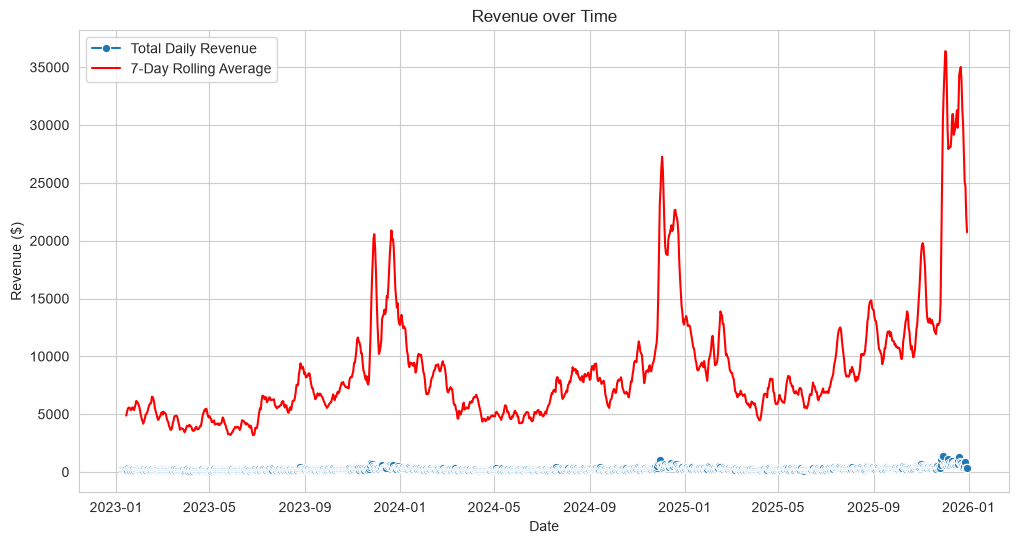

In [64]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='total_revenue', marker='o', label='Total Daily Revenue')

daily_plot = df.groupby(df.index)['total_revenue'].sum().to_frame()
daily_plot['revenue_7d_avg'] = daily_plot['total_revenue'].rolling(window=7).mean()

sns.lineplot(data=daily_plot, x=daily_plot.index, y='revenue_7d_avg', label='7-Day Rolling Average', color='red')

plt.title("Revenue over Time")
plt.ylabel("Revenue ($)")
plt.xlabel("Date")
plt.legend()
plt.show()

## Preparing the data for training

In [ ]:
master_df.set_index('date', inplace=True)

In [ ]:
master_df.head(10)

,sku,total_units,total_revenue,is_promo_active,category,base_price,units_lag_7,units_rolling_7d_avg,month,day_of_week
date,,,,,,,,,,
2023-01-11,ACC-001,5,98.79,0,accessories,20.65,4.0,4.000000,1,Wednesday
2023-01-12,ACC-001,3,59.16,0,accessories,20.65,3.0,4.000000,1,Thursday
2023-01-14,ACC-001,1,19.60,0,accessories,20.65,2.0,3.857143,1,Saturday
2023-01-15,ACC-001,2,40.68,0,accessories,20.65,1.0,4.000000,1,Sunday
2023-01-18,ACC-001,6,122.86,0,accessories,20.65,9.0,3.571429,1,Wednesday
2023-01-21,ACC-001,3,60.63,0,accessories,20.65,7.0,3.000000,1,Saturday
2023-01-23,ACC-001,4,79.93,0,accessories,20.65,1.0,3.428571,1,Monday
2023-01-26,ACC-001,2,41.34,0,accessories,20.65,5.0,3.000000,1,Thursday
2023-02-02,ACC-001,2,41.04,0,accessories,20.65,3.0,2.857143,2,Thursday


In [ ]:
master_df['category'] = master_df['category'].astype('category')
master_df['sku'] = master_df['sku'].astype('category')


In [ ]:
# Time-Series Split
split_date = master_df.index.max() - pd.Timedelta(days=30)

train_df = master_df[master_df.index <= split_date]
test_df = master_df[master_df.index > split_date]


In [62]:
print(df.index.is_unique)
print(df.index.duplicated().sum())

False
30648
